In [7]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

+ Step 1. Open the data file and read the general information

In [8]:
#data = pd.read_csv('datasets/logs_exp.csv', sep='\t')
data = pd.read_csv("https://code.s3.yandex.net/datasets/logs_exp.csv", sep='\t')
data.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [10]:
data.describe()

,DeviceIDHash,EventTimestamp,ExpId
count,2.441260e+05,2.441260e+05,244126.000000
mean,4.627568e+18,1.564914e+09,247.022296
std,2.642425e+18,1.771343e+05,0.824434
min,6.888747e+15,1.564030e+09,246.000000
25%,2.372212e+18,1.564757e+09,246.000000
50%,4.623192e+18,1.564919e+09,247.000000
75%,6.932517e+18,1.565075e+09,248.000000
max,9.222603e+18,1.565213e+09,248.000000


Everything's great. We don't have missing values. Data types match our expectations. We can clearly see that we have all three experiments: 246, 247, 248

+ Rename the columns in a way that's convenient for you

In [11]:
data.rename(columns={
    'EventName': 'event',
    'DeviceIDHash': 'user',
    'EventTimestamp': 'timestamp',
    'ExpId': 'exp_id',
}, inplace=True)
data.head()

,event,user,timestamp,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


+ Check for missing values and data types. Correct the data if needed

As we've already seen, everything's OK

+ Add a date and time column and a separate column for dates

In [12]:
data['date_time'] = pd.to_datetime(data['timestamp'], unit='s')
data['date'] = data['date_time'].dt.floor('1D')
data.head()

,event,user,timestamp,exp_id,date_time,date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


+ How many events are in the logs? 
+ How many users are in the logs?
+ What's the average number of events per user?

In [13]:
events = len(data)
users = len(data['user'].unique())
events_per_user = events / users
print(f'{events} events')
print(f'{users} users')
print(f'{events_per_user} events_per_user')

244126 events
7551 users
32.33028737915508 events_per_user


+ What period of time does the data cover?  
  Find the maximum and the minimum date.  
  Plot a histogram by date and time.  
  Can you be sure that you have equally complete data for the entire period? Older events may be included in logs for more recent days for some users for technical reasons, and this delay could skew the overall picture.  
  Find the moment at which the data starts to be complete and ignore the earlier section. What period does the data actually represent?

In [37]:
print(data['date_time'].min()," - " ,data['date_time'].max())

2019-07-31 21:00:57  -  2019-08-07 21:15:17


<Axes: >

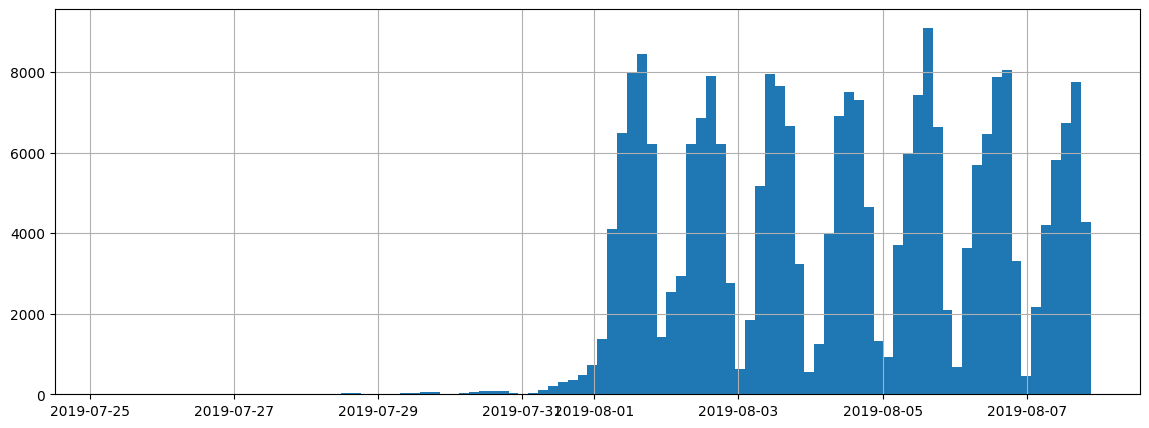

In [15]:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
data['date_time'].hist(bins=100, figsize=(14, 5))

<Axes: xlabel='date'>

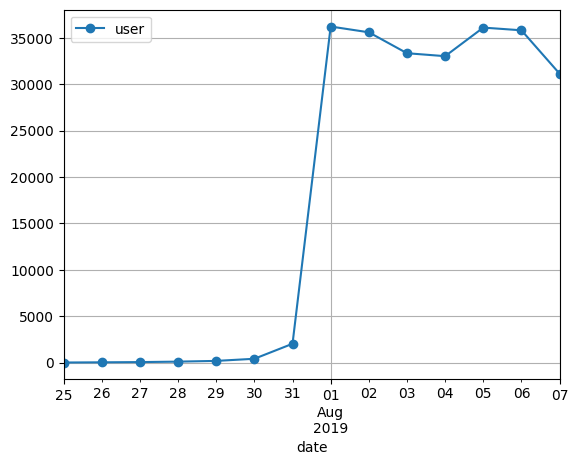

In [16]:
data.pivot_table(index='date', values='user', aggfunc='count').plot(style='o-', grid=True)

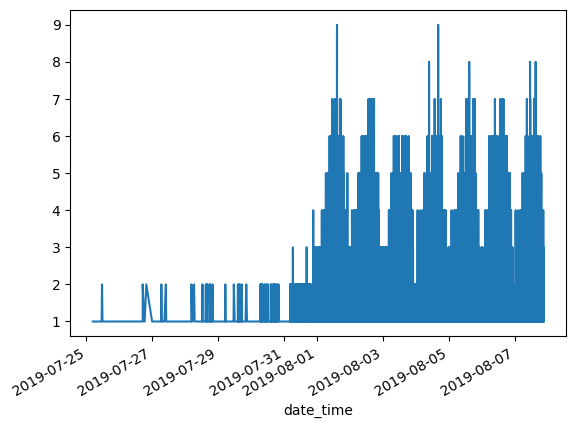

,event,user,timestamp,exp_id,date_time,date
1990,MainScreenAppear,7701922487875823903,1564606857,247,2019-07-31 21:00:57,2019-07-31
1991,MainScreenAppear,2539077412200498909,1564606905,247,2019-07-31 21:01:45,2019-07-31
1992,OffersScreenAppear,3286987355161301427,1564606941,248,2019-07-31 21:02:21,2019-07-31
1993,OffersScreenAppear,3187166762535343300,1564606943,247,2019-07-31 21:02:23,2019-07-31
1994,MainScreenAppear,1118952406011435924,1564607005,248,2019-07-31 21:03:25,2019-07-31


In [17]:

data.groupby("date_time")["user"].count().plot()
plt.show()


data.query('date_time > "2019-07-31 21:00"', inplace=True)
data.head()

<Axes: >

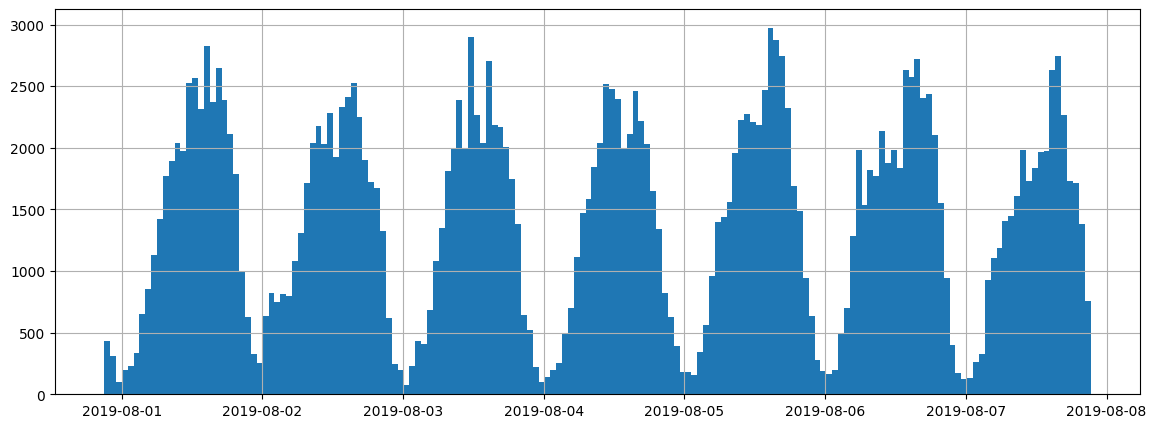

In [18]:
data['date_time'].hist(bins=7*24, figsize=(14, 5))

We have the data for the week from 2019-08-01 to 2019-08-07 (with a three hour shift).
Students are not likely to notice such a slight shift, so I doubt that we should focus on that.

+ Did you lose many events and users when excluding the older data?

In [19]:
events = len(data)
users = len(data['user'].unique())
events_per_user = events / users
print(f'{events} events')
print(f'{users} users')
print(f'{events_per_user} events_per_user')

242136 events
7538 users
32.12204828867073 events_per_user


We lost less than 1%.

+ Make sure you have users from all three experimental groups.

In [20]:
data['exp_id'].value_counts()

exp_id
248    85039
246    79679
247    77418
Name: count, dtype: int64

+ See what events are in the logs and their frequency of occurrence. Sort them by frequency. 

In [21]:
data.pivot_table(index='event', values='user', aggfunc='count').sort_values('user', ascending=False)

,user
event,
MainScreenAppear,117992
OffersScreenAppear,46548
CartScreenAppear,42406
PaymentScreenSuccessful,34146
Tutorial,1044


+ Find the number of users who performed each of these actions. Sort the events by the number of users. Calculate the proportion of users who performed the action at least once.

In [22]:
users_per_event = (
    data
    .pivot_table(index='event', values='user', aggfunc=lambda x: x.nunique())
    .sort_values('user', ascending=False)
)
users_per_event

,user
event,
MainScreenAppear,7423
OffersScreenAppear,4597
CartScreenAppear,3736
PaymentScreenSuccessful,3540
Tutorial,843


In [23]:
users_per_event / len(data['user'].unique())

,user
event,
MainScreenAppear,0.984744
OffersScreenAppear,0.609843
CartScreenAppear,0.495622
PaymentScreenSuccessful,0.469621
Tutorial,0.111833


+ In what order do you think the actions took place. Are all of them part of a single sequence? You don't need to take them into account when calculating the funnel.

We'll take all the data in decreasing order of frequency, except Tutorial

+ Use the event funnel to find the share of users that proceed from each stage to the next. (For instance, for the sequence of events A → B → C, calculate the ratio of users at stage B to the number of users at stage A and the ratio of users at stage C to the number at stage B.) 

In [24]:
users_funnel = users_per_event[:-1]
users_funnel = (users_funnel / users_funnel.shift())[1:]
users_funnel

,user
event,
OffersScreenAppear,0.619291
CartScreenAppear,0.812704
PaymentScreenSuccessful,0.947537


+ At what stage do you lose most of users?

TThe most considerable drop is observed at the first stage, on passing from MainScreenAppear to OffersScreenAppear. Probably the mechanics should be enhanced so that users passed to OffersScreen.

+ What share of users make the entire journey from their first event to payment?

In [25]:
print('{} make it from the main screen to successful payment'
      .format((users_per_event.loc['PaymentScreenSuccessful'] / users_per_event.loc['MainScreenAppear'])['user']))

0.47689613363869054 make it from the main screen to successful payment


+ How many users are there in each group?

In [26]:
users_per_group = data.pivot_table(index='exp_id', values='user', aggfunc=lambda x: x.nunique())['user']
users_per_group

exp_id
246    2484
247    2517
248    2537
Name: user, dtype: int64

+ We have two control groups in the A/A test, where we check our mechanisms and calculations. See if there is a statistically significant difference between the samples 246 and 247.
+ Select the most popular event. In each of the control groups, find the number of users who performed this action. Find their share. Check whether the difference between the groups is statistically significant. Repeat the procedure for all other events (it will save time if you create a special function for this test). Can you that the groups were split properly?

In [27]:
users_events_per_group = data.pivot_table(index='event', values='user', columns='exp_id', aggfunc=lambda x: x.nunique())
users_events_per_group

exp_id,246,247,248
event,,,
CartScreenAppear,1266,1239,1231
MainScreenAppear,2450,2479,2494
OffersScreenAppear,1542,1524,1531
PaymentScreenSuccessful,1200,1158,1182
Tutorial,278,284,281


In [28]:
from scipy import stats
import numpy as np
import math

def check_hypothesis(successes1, successes2, trials1, trials2, alpha=0.01):
    # proportion of successes in the first group:
    p1 = successes1/trials1

    # proportion of successes in the second group:
    p2 = successes2/trials2

    # proportion of successes in the combined dataset:
    p_combined = (successes1 + successes2) / (trials1 + trials2)

    # the difference of proportions in datasets
    difference = p1 - p2
    
    # calculating the statistic in standard deviations of standard normal distribution
    z_value = difference / math.sqrt(p_combined * (1 - p_combined) * (1/trials1 + 1/trials2))

    # setting standard normal distribution (mean= 0, standard deviation=1)
    distr = stats.norm(0, 1) 

    p_value = (1 - distr.cdf(abs(z_value))) * 2

    print('p-value: ', p_value)

    if (p_value < alpha):
        print("Rejecting the null hypothesis: there is a significant difference between the proportions")
    else:
        print("Failed to reject the null hypothesis, there is no reason to consider the proportions different")  

In [29]:
check_hypothesis(users_events_per_group.loc['MainScreenAppear', 246],
                 users_events_per_group.loc['MainScreenAppear', 247],
                 users_per_group.loc[246],
                 users_per_group.loc[247],
                )                 

p-value:  0.6756217702005545
Failed to reject the null hypothesis, there is no reason to consider the proportions different


In [30]:
def check_event_hypithesis(users_events_per_group, users_per_group,
                           event,
                           exp1, exp2
                          ):
    frac1 = users_events_per_group.loc[event, exp1] / users_per_group.loc[exp1]
    frac2 = users_events_per_group.loc[event, exp2] / users_per_group.loc[exp2]
    print(f'{frac1} with {event} event in group {exp1}')
    print(f'{frac2} with {event} event in group {exp2}')
    check_hypothesis(users_events_per_group.loc[event, exp1],
                     users_events_per_group.loc[event, exp2],
                     users_per_group.loc[exp1],
                     users_per_group.loc[exp2],
                    )

In [31]:
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group, users_per_group,
                          event, 246, 247)
    print()

0.5096618357487923 with CartScreenAppear event in group 246
0.4922526817640048 with CartScreenAppear event in group 247
p-value:  0.2182812140633792
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9863123993558777 with MainScreenAppear event in group 246
0.9849026618990863 with MainScreenAppear event in group 247
p-value:  0.6756217702005545
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6207729468599034 with OffersScreenAppear event in group 246
0.6054827175208581 with OffersScreenAppear event in group 247
p-value:  0.26698769175859516
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.4830917874396135 with PaymentScreenSuccessful event in group 246
0.4600715137067938 with PaymentScreenSuccessful event in group 247
p-value:  0.10298394982948822
Failed to reject the null hypothesis, there is no reason to consider the proportions different



We can state with a high degree of confidence that the results in control groups are equal. I.e., division into groups and calculations seem to be correct.

+ Do the same thing for the group with altered fonts. Compare the results with those of each of the control groups for each event in isolation. Compare the results with the combined results for the control groups. What conclusions can you draw from the experiment?

In [32]:
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group, users_per_group,
                          event, 246, 248)
    print()

0.5096618357487923 with CartScreenAppear event in group 246
0.48521876231769806 with CartScreenAppear event in group 248
p-value:  0.08328412977507749
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9863123993558777 with MainScreenAppear event in group 246
0.9830508474576272 with MainScreenAppear event in group 248
p-value:  0.34705881021236484
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6207729468599034 with OffersScreenAppear event in group 246
0.6034686637761135 with OffersScreenAppear event in group 248
p-value:  0.20836205402738917
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.4830917874396135 with PaymentScreenSuccessful event in group 246
0.4659046117461569 with PaymentScreenSuccessful event in group 248
p-value:  0.22269358994682742
Failed to reject the null hypothesis, there is no reason to consider the proportions differen

We can't see any great difference here either. Although the proportion of events per user has decreased, the differences remain statistically insignificant.

In [33]:
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group, users_per_group,
                          event, 247, 248)
    print()

0.4922526817640048 with CartScreenAppear event in group 247
0.48521876231769806 with CartScreenAppear event in group 248
p-value:  0.6169517476996997
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9849026618990863 with MainScreenAppear event in group 247
0.9830508474576272 with MainScreenAppear event in group 248
p-value:  0.6001661582453706
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6054827175208581 with OffersScreenAppear event in group 247
0.6034686637761135 with OffersScreenAppear event in group 248
p-value:  0.8835956656016957
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.4600715137067938 with PaymentScreenSuccessful event in group 247
0.4659046117461569 with PaymentScreenSuccessful event in group 248
p-value:  0.6775413642906454
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0

In this case all the events, except payment, grew less in number, but all the differences are really slight.

In [34]:
users_events_per_group_control = users_events_per_group.copy()
users_events_per_group_control.loc[:, 247] += users_events_per_group_control.loc[:, 246]
users_events_per_group_control.drop(columns=246, inplace=True)
users_events_per_group_control

exp_id,247,248
event,,
CartScreenAppear,2505,1231
MainScreenAppear,4929,2494
OffersScreenAppear,3066,1531
PaymentScreenSuccessful,2358,1182
Tutorial,562,281


In [35]:
users_per_group_control = users_per_group.copy()
users_per_group_control.loc[247] += users_per_group_control.loc[246]
users_per_group_control.drop(246, inplace=True)
users_per_group_control

exp_id
247    5001
248    2537
Name: user, dtype: int64

In [36]:
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group_control, users_per_group_control,
                          event, 247, 248)
    print()

0.5008998200359928 with CartScreenAppear event in group 247
0.48521876231769806 with CartScreenAppear event in group 248
p-value:  0.19819340844527744
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9856028794241152 with MainScreenAppear event in group 247
0.9830508474576272 with MainScreenAppear event in group 248
p-value:  0.39298914928006035
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6130773845230953 with OffersScreenAppear event in group 247
0.6034686637761135 with OffersScreenAppear event in group 248
p-value:  0.418998284007599
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.471505698860228 with PaymentScreenSuccessful event in group 247
0.4659046117461569 with PaymentScreenSuccessful event in group 248
p-value:  0.6452057673098244
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0

Although all proportions have decreased, the differences are far from statistical significance.